# FC-TFI QRC on Lorenz-63 (multivariate next-step)

Continuous FC-TFI quantum reservoir (no rewind cutoff, no drive reset) for 3D Lorenz-63 next-step forecasting.

**Data (Hamhoum et al. 2025/26 protocol, with corrections noted):**
- 1000 samples, $\Delta t = 0.1$, adaptive RK45 (`scipy.integrate.solve_ivp`)
- Parameters $(a,b,c)=(10,28,8/3)$ — paper prints $c=3/8$; we use the canonical chaotic value $8/3$
- Initial state $(x_0,y_0,z_0)=(1,1,1)$, no generator burn-in
- Chronological 80/20 split; per-variable min–max fit on train only; encoding clips to $[0,1]$

**QRC (our FC-TFI, not the paper’s Opt-NN-TFI / rewind protocol):**
- 3 drive + 5 hidden = 8 qubits; encode $u_i \mapsto RY(\pi u_i)$ on drive qubits
- Continuous state (no reset / no washout); $J\sim\mathcal{N}(0,0.5)$, $h=0.1$, $t=0.5$, 2 layers, 3 Trotter steps
- Backends: noiseless statevector + amplitude damping ($\gamma=10^{-3}$)

**Pipeline**
1. Generate / scale Lorenz-63; form next-step pairs $H[t]\to U[t+1]$
2. Run FC-TFI on both backends (3 matched $J$ seeds)
3. Persistence + multivariate delay Ridge baselines
4. Noiseless per-drive OTOC + multivariate STM diagnostics


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import optuna
from scipy.integrate import solve_ivp
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp, Operator, SuperOp
from qiskit_aer.utils import insert_noise
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.set_printoptions(precision=4, suppress=True)


In [2]:
# ── Config ───────────────────────────────────────────────────────────────────
BACKEND = "statevector"  # display default; both backends always run

QRC_CONFIG = {
    "n_drive_qubits": 3,          # one RY per Lorenz variable (x, y, z)
    "n_hidden_qubits": 5,
    "num_layers_per_event": 2,
    "n_iterations": 3,            # resample J each iteration (matched across backends)
    "random_seed": 42,
    "amplitude_damping_gamma": 1e-3,
    "J_std": 0.5,
    "h": 0.1,
    "t": 0.5,
    "n_trotter_steps": 3,
}

LORENZ_CONFIG = {
    "T": 1000,
    "dt": 0.1,
    "a": 10.0,
    "b": 28.0,
    "c": 8.0 / 3.0,               # canonical; paper prints 3/8
    "x0": (1.0, 1.0, 1.0),
    "rtol": 1e-9,
    "atol": 1e-12,
    "train_frac": 0.8,           # chronological 80/20; no separate val set
    "var_names": ("x", "y", "z"),
}

BASELINE_CONFIG = {
    "delay": 10,                 # current + 10 prior 3D points → 33 features
}

OTOC_CONFIG = {
    "n_steps": 40,
    # OTOC only on noiseless backend (8-qubit noisy SuperOp is infeasible)
}

n_qubits = QRC_CONFIG["n_drive_qubits"] + QRC_CONFIG["n_hidden_qubits"]
assert QRC_CONFIG["n_drive_qubits"] == 3
assert QRC_CONFIG["n_hidden_qubits"] >= 1
assert n_qubits == 8

BACKENDS_TO_RUN = ("statevector", "amplitude_damping")

print("BACKEND:", BACKEND)
print("n_qubits:", n_qubits,
      f"(drive={QRC_CONFIG['n_drive_qubits']}, hidden={QRC_CONFIG['n_hidden_qubits']})")
print("QRC_CONFIG:", QRC_CONFIG)
print("LORENZ_CONFIG:", LORENZ_CONFIG)


BACKEND: statevector
n_qubits: 8 (drive=3, hidden=5)
QRC_CONFIG: {'n_drive_qubits': 3, 'n_hidden_qubits': 5, 'num_layers_per_event': 2, 'n_iterations': 3, 'random_seed': 42, 'amplitude_damping_gamma': 0.001, 'J_std': 0.5, 'h': 0.1, 't': 0.5, 'n_trotter_steps': 3}
LORENZ_CONFIG: {'T': 1000, 'dt': 0.1, 'a': 10.0, 'b': 28.0, 'c': 2.6666666666666665, 'x0': (1.0, 1.0, 1.0), 'rtol': 1e-09, 'atol': 1e-12, 'train_frac': 0.8, 'var_names': ('x', 'y', 'z')}


## Lorenz-63 data


In [3]:
# ── Lorenz-63 generator (adaptive RK45) ──────────────────────────────────────
def lorenz63_rhs(t, state, a, b, c):
    x, y, z = state
    return [a * (y - x), x * (b - z) - y, x * y - c * z]


def generate_lorenz63(
    T=1000,
    dt=0.1,
    a=10.0,
    b=28.0,
    c=8.0 / 3.0,
    x0=(1.0, 1.0, 1.0),
    rtol=1e-9,
    atol=1e-12,
):
    """Return (t, U) with U shape (T, 3), samples at 0, dt, ..., (T-1)*dt."""
    t_eval = np.arange(T, dtype=float) * dt
    sol = solve_ivp(
        lorenz63_rhs,
        (t_eval[0], t_eval[-1]),
        np.asarray(x0, dtype=float),
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
        args=(a, b, c),
        dense_output=False,
    )
    assert sol.success, f"RK45 failed: {sol.message}"
    U = sol.y.T.astype(float)
    assert U.shape == (T, 3)
    assert np.all(np.isfinite(U))
    assert np.allclose(sol.t, t_eval)
    return t_eval, U


def nmse(y_true, y_pred):
    """Normalized MSE: MSE / var(y_true). Works for 1D or 2D (flattened)."""
    yt = np.asarray(y_true, dtype=float).ravel()
    yp = np.asarray(y_pred, dtype=float).ravel()
    var = np.var(yt)
    if var < 1e-15:
        return np.nan
    return float(mean_squared_error(yt, yp) / var)


def per_variable_nmse(y_true, y_pred, names=("x", "y", "z")):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    assert yt.ndim == 2 and yt.shape == yp.shape
    return {names[i]: nmse(yt[:, i], yp[:, i]) for i in range(yt.shape[1])}


# Generate trajectory
t_lorenz, U_raw = generate_lorenz63(
    T=LORENZ_CONFIG["T"],
    dt=LORENZ_CONFIG["dt"],
    a=LORENZ_CONFIG["a"],
    b=LORENZ_CONFIG["b"],
    c=LORENZ_CONFIG["c"],
    x0=LORENZ_CONFIG["x0"],
    rtol=LORENZ_CONFIG["rtol"],
    atol=LORENZ_CONFIG["atol"],
)

n_train = int(LORENZ_CONFIG["T"] * LORENZ_CONFIG["train_frac"])
n_test = LORENZ_CONFIG["T"] - n_train
assert n_train == 800 and n_test == 200

# Train-only min–max per variable
scaler = MinMaxScaler()
scaler.fit(U_raw[:n_train])
U_scaled = scaler.transform(U_raw)

# Encoding clip to [0,1]; targets stay unclipped scaled values
U_enc = np.clip(U_scaled, 0.0, 1.0)
n_clip_below = int(np.sum(U_scaled < 0.0))
n_clip_above = int(np.sum(U_scaled > 1.0))
print(
    f"Clipping (encoding only): below=0 → {n_clip_below}, above=1 → {n_clip_above} "
    f"(of {U_scaled.size} values)"
)

# Next-step alignment: feature at t predicts U[t+1]
# Reservoir evolves on U_enc[0..T-2]; targets are U_scaled[1..T-1]
U_drive = U_enc[:-1]          # (999, 3) — clipped for encoding
Y_target = U_scaled[1:]       # (999, 3) — unclipped scaled targets
assert U_drive.shape == (999, 3)
assert Y_target.shape == (999, 3)

# Split indices into drive/target arrays (length 999)
# train: indices 0..798 → features U[0..798], targets U[1..799]
# test:  indices 799..998 → features U[799..998], targets U[800..999]
n_tr_pairs = n_train - 1       # 799
n_te_pairs = n_test            # 200
assert n_tr_pairs + n_te_pairs == 999

U_tr, Y_tr = U_drive[:n_tr_pairs], Y_target[:n_tr_pairs]
U_te, Y_te = U_drive[n_tr_pairs:], Y_target[n_tr_pairs:]
assert U_tr.shape == (799, 3) and Y_tr.shape == (799, 3)
assert U_te.shape == (200, 3) and Y_te.shape == (200, 3)

print(
    f"Lorenz-63: T={len(U_raw)}, train/test raw = {n_train}/{n_test}, "
    f"next-step train/test pairs = {n_tr_pairs}/{n_te_pairs}"
)
print(f"Raw range: min={U_raw.min(axis=0)}, max={U_raw.max(axis=0)}")
print(f"Scaled train range: min={U_scaled[:n_train].min(axis=0)}, "
      f"max={U_scaled[:n_train].max(axis=0)}")


Clipping (encoding only): below=0 → 0, above=1 → 0 (of 3000 values)
Lorenz-63: T=1000, train/test raw = 800/200, next-step train/test pairs = 799/200
Raw range: min=[-17.2331 -24.1539   1.    ], max=[18.5584 27.1835 46.7578]
Scaled train range: min=[0. 0. 0.], max=[1. 1. 1.]


cell_5:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


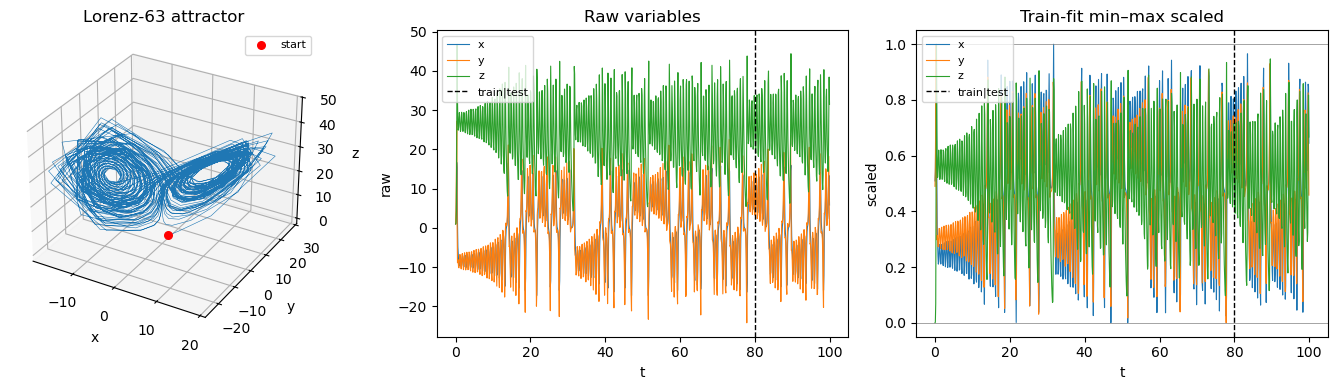

In [4]:
# ── Lorenz visualizations ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot(U_raw[:, 0], U_raw[:, 1], U_raw[:, 2], lw=0.4, color="C0")
ax.scatter(*U_raw[0], c="red", s=30, label="start")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Lorenz-63 attractor")
ax.legend(fontsize=8)

ax = fig.add_subplot(1, 3, 2)
for i, name in enumerate(LORENZ_CONFIG["var_names"]):
    ax.plot(t_lorenz, U_raw[:, i], label=name, lw=0.8)
ax.axvline(t_lorenz[n_train], color="k", ls="--", lw=1, label="train|test")
ax.set_xlabel("t"); ax.set_ylabel("raw")
ax.set_title("Raw variables")
ax.legend(fontsize=8)

ax = fig.add_subplot(1, 3, 3)
for i, name in enumerate(LORENZ_CONFIG["var_names"]):
    ax.plot(t_lorenz, U_scaled[:, i], label=name, lw=0.8)
ax.axvline(t_lorenz[n_train], color="k", ls="--", lw=1, label="train|test")
ax.axhline(0, color="gray", lw=0.5); ax.axhline(1, color="gray", lw=0.5)
ax.set_xlabel("t"); ax.set_ylabel("scaled")
ax.set_title("Train-fit min–max scaled")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## FC-TFI reservoir (multivariate continuous)


In [5]:
# ── FC-TFI Hamiltonian + multivariate encoding ───────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.1, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def u_to_theta(u):
    """Map u in [0, 1] → θ = πu (linear encoding)."""
    return float(np.clip(u, 0.0, 1.0) * np.pi)


def encode_drive(qc, thetas, n_drive_qubits):
    """Apply RY(θ_i) on each dedicated drive qubit."""
    thetas = np.asarray(thetas, dtype=float).reshape(-1)
    assert len(thetas) == n_drive_qubits
    for i in range(n_drive_qubits):
        qc.ry(thetas[i], i)


def build_event_step_circuit(
    thetas, ising_params, num_layers, n_qubits, n_drive_qubits, apply_initial_h,
    n_trotter_steps=3,
):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_drive(qc, thetas, n_drive_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
        encode_drive(qc, thetas, n_drive_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
    return qc


def pauli_string(n_qubits, basis, qubit):
    label = ['I'] * n_qubits
    label[n_qubits - 1 - qubit] = basis
    return ''.join(label)


def pauli_expectations(state, n_qubits):
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        for q in range(n_qubits):
            op = SparsePauliOp(pauli_string(n_qubits, basis, q))
            expectations[basis_idx * n_qubits + q] = state.expectation_value(op).real
    zz = np.zeros(n_qubits)
    for i in range(n_qubits):
        j = (i + 1) % n_qubits
        label = ['I'] * n_qubits
        label[n_qubits - 1 - i] = 'Z'
        label[n_qubits - 1 - j] = 'Z'
        op = SparsePauliOp(''.join(label))
        zz[i] = state.expectation_value(op).real
    return np.concatenate([expectations, zz])


In [6]:
# ── Amplitude damping via AerSimulator + NoiseModel ──────────────────────────
def build_amplitude_damping_noise_model(gamma, n_qubits):
    """Local amplitude damping on every 1q/2q gate used by the FC-TFI step."""
    if gamma <= 0.0:
        return None
    nm = NoiseModel()
    err1 = amplitude_damping_error(gamma)
    for gate in ("ry", "rx", "rz", "h", "id"):
        nm.add_all_qubit_quantum_error(err1, [gate])
    err2 = err1.tensor(err1)
    nm.add_all_qubit_quantum_error(err2, ["cx"])
    return nm


def make_aer_density_simulator(gamma, n_qubits, seed=42):
    nm = build_amplitude_damping_noise_model(gamma, n_qubits)
    kwargs = {"method": "density_matrix", "seed_simulator": seed}
    if nm is not None:
        kwargs["noise_model"] = nm
    return AerSimulator(**kwargs)


def aer_evolve_density_matrix(sim, rho, step_circuit, n_qubits):
    """One noisy step: load ρ, apply step under NoiseModel, save ρ'."""
    qc = QuantumCircuit(n_qubits)
    if hasattr(qc, "set_density_matrix"):
        qc.set_density_matrix(rho)
    else:
        from qiskit_aer.library import SetDensityMatrix
        qc.append(SetDensityMatrix(rho), range(n_qubits))
    qc.compose(step_circuit, inplace=True)
    if hasattr(qc, "save_density_matrix"):
        qc.save_density_matrix(label="rho")
    else:
        from qiskit_aer.library import SaveDensityMatrix
        qc.append(SaveDensityMatrix(n_qubits, label="rho"), range(n_qubits))

    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1).result()
    data = result.data(0)
    rho_out = data["rho"]
    if not isinstance(rho_out, DensityMatrix):
        rho_out = DensityMatrix(rho_out)
    return rho_out


In [7]:
# ── Continuous multivariate reservoir runner ─────────────────────────────────
def run_quantum_reservoir(
    u_series,
    ising_params,
    config,
    backend,
    initial_state=None,
    aer_sim=None,
):
    """Drive continuous FC-TFI with multivariate u_t (T, d); return features + state.

    Backends:
      - statevector: pure Statevector.evolve (no noise)
      - amplitude_damping: AerSimulator(method='density_matrix') + AD NoiseModel

    No drive reset / no washout — state persists across the full series.
    """
    n_drive = config["n_drive_qubits"]
    n_hid = config["n_hidden_qubits"]
    n_qubits = n_drive + n_hid
    num_layers = config["num_layers_per_event"]
    n_trotter = config.get("n_trotter_steps", 3)
    gamma = float(config.get("amplitude_damping_gamma", 0.0)) if backend == "amplitude_damping" else 0.0

    u_series = np.asarray(u_series, dtype=float)
    if u_series.ndim == 1:
        u_series = u_series.reshape(-1, 1)
    assert u_series.ndim == 2 and u_series.shape[1] == n_drive, (
        f"Expected (T, {n_drive}), got {u_series.shape}"
    )
    m = len(u_series)
    n_obs = 4 * n_qubits
    H = np.zeros((m, n_obs))

    if backend == "statevector":
        state = Statevector.from_label("0" * n_qubits) if initial_state is None else initial_state
        sim = None
    elif backend == "amplitude_damping":
        state = DensityMatrix.from_label("0" * n_qubits) if initial_state is None else initial_state
        if not isinstance(state, DensityMatrix):
            state = DensityMatrix(state)
        sim = aer_sim or make_aer_density_simulator(
            gamma, n_qubits, seed=config.get("random_seed", 42)
        )
    else:
        raise ValueError(f"Unknown backend: {backend}")

    apply_h = initial_state is None
    for i, u_vec in enumerate(u_series):
        thetas = [u_to_theta(u) for u in u_vec]
        step = build_event_step_circuit(
            thetas, ising_params, num_layers, n_qubits, n_drive,
            apply_initial_h=apply_h,
            n_trotter_steps=n_trotter,
        )
        apply_h = False

        if backend == "statevector":
            state = state.evolve(step)
        else:
            state = aer_evolve_density_matrix(sim, state, step, n_qubits)

        H[i] = pauli_expectations(state, n_qubits)
        if i % 100 == 0:
            print(f"  sample {i+1}/{m}", end="\r")
    print()
    return H, state


## Ridge readout + Lorenz experiments


In [8]:
# ── Multi-output Ridge tuning / fit ──────────────────────────────────────────
def fit_ridge_timeseries(H_train, y_train, seed=42, n_trials=30):
    """Tune Ridge α via TimeSeriesSplit CV on training block only (no holdout val)."""
    y_train = np.asarray(y_train, dtype=float)

    def cv_mse(alpha):
        n = len(y_train)
        if n < 2:
            m = Ridge(alpha=alpha)
            m.fit(H_train, y_train)
            return float(mean_squared_error(y_train, m.predict(H_train)))
        n_folds = min(3, n - 1)
        tscv = TimeSeriesSplit(n_splits=n_folds)
        mses = []
        for tr, vl in tscv.split(H_train):
            m = Ridge(alpha=alpha)
            m.fit(H_train[tr], y_train[tr])
            mses.append(mean_squared_error(y_train[vl], m.predict(H_train[vl])))
        return float(np.mean(mses))

    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-4, 1e6, log=True)
        return cv_mse(alpha)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=n_trials)
    alpha = study.best_params["alpha"]
    model = Ridge(alpha=alpha)
    model.fit(H_train, y_train)
    return model, {"alpha": alpha, "cv_mse": study.best_value}


def regression_metrics(y_true, y_pred, names=("x", "y", "z")):
    """Aggregate + per-variable NMSE; also RMSE/MAE/R2 on flattened arrays."""
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    return {
        "nmse": nmse(yt, yp),
        "nmse_per_var": per_variable_nmse(yt, yp, names),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "mae": float(mean_absolute_error(yt, yp)),
        "r2": float(r2_score(yt, yp)),
    }


def run_lorenz_qrc(backend, config, n_qubits, U_full_drive, Y_full, n_tr_pairs):
    """Run continuous reservoir across full drive series; fit on train pairs.

    State never resets between train and test — continuous handoff.
    Identical J seeds across backends via shared RNG offsets.
    """
    results = []
    preds = []
    last_artifacts = None

    for it in range(config["n_iterations"]):
        print(f"\n=== Lorenz-63 | {backend} | iter {it+1}/{config['n_iterations']} ===")
        rng = np.random.default_rng(config["random_seed"] + 17 * it)
        ising = generate_ising_params(
            n_qubits, rng,
            J_std=config["J_std"], h=config["h"], t=config["t"],
        )

        aer_sim = None
        if backend == "amplitude_damping":
            aer_sim = make_aer_density_simulator(
                float(config.get("amplitude_damping_gamma", 0.0)),
                n_qubits,
                seed=config["random_seed"] + it,
            )

        print("  reservoir (full continuous drive)...")
        H_full, _ = run_quantum_reservoir(
            U_full_drive, ising, config, backend, aer_sim=aer_sim,
        )
        assert H_full.shape == (len(U_full_drive), 4 * n_qubits)

        H_tr = H_full[:n_tr_pairs]
        H_te = H_full[n_tr_pairs:]
        Y_tr = Y_full[:n_tr_pairs]
        Y_te = Y_full[n_tr_pairs:]

        model, info = fit_ridge_timeseries(
            H_tr, Y_tr, seed=config["random_seed"] + it,
        )
        yhat = model.predict(H_te)
        mets = regression_metrics(Y_te, yhat, LORENZ_CONFIG["var_names"])
        # Inverse-transform metrics in original Lorenz units
        yhat_raw = scaler.inverse_transform(yhat)
        yte_raw = scaler.inverse_transform(Y_te)
        mets_raw = regression_metrics(yte_raw, yhat_raw, LORENZ_CONFIG["var_names"])

        rec = {
            "iteration": it,
            "alpha": info["alpha"],
            "cv_mse": info["cv_mse"],
            "test_nmse": mets["nmse"],
            "test_nmse_per_var": mets["nmse_per_var"],
            "test_rmse_scaled": mets["rmse"],
            "test_rmse_raw": mets_raw["rmse"],
            "test_mae_raw": mets_raw["mae"],
            "test_r2_raw": mets_raw["r2"],
            "yhat": yhat,
            "ising": ising,
        }
        print(
            f"  alpha={rec['alpha']:.3g} | test NMSE={rec['test_nmse']:.4f} | "
            f"RMSE_raw={rec['test_rmse_raw']:.4f} | "
            f"per-var NMSE={rec['test_nmse_per_var']}"
        )
        results.append(rec)
        preds.append(yhat)
        last_artifacts = {
            "ising": ising,
            "H_full": H_full,
            "H_train": H_tr,
            "H_test": H_te,
            "U_drive": np.asarray(U_full_drive, dtype=float),
            "U_train": np.asarray(U_full_drive[:n_tr_pairs], dtype=float),
            "Y_train": np.asarray(Y_tr, dtype=float),
            "Y_test": np.asarray(Y_te, dtype=float),
            "backend": backend,
            "gamma": float(config.get("amplitude_damping_gamma", 0.0))
            if backend == "amplitude_damping"
            else 0.0,
        }

    stack = np.stack(preds, axis=0)  # (n_iter, n_te, 3)
    ensemble = np.mean(stack, axis=0)
    seed_nmses = np.array([r["test_nmse"] for r in results])
    ens_mets = regression_metrics(Y_full[n_tr_pairs:], ensemble, LORENZ_CONFIG["var_names"])
    ens_raw = regression_metrics(
        scaler.inverse_transform(Y_full[n_tr_pairs:]),
        scaler.inverse_transform(ensemble),
        LORENZ_CONFIG["var_names"],
    )
    summary = {
        "backend": backend,
        "seed_nmse_mean": float(seed_nmses.mean()),
        "seed_nmse_std": float(seed_nmses.std(ddof=0)),
        "ensemble_nmse": ens_mets["nmse"],
        "ensemble_nmse_per_var": ens_mets["nmse_per_var"],
        "ensemble_rmse_raw": ens_raw["rmse"],
        "ensemble_mae_raw": ens_raw["mae"],
        "ensemble_r2_raw": ens_raw["r2"],
        "y_test": Y_full[n_tr_pairs:],
        "yhat": ensemble,
        "results": results,
        "artifacts": last_artifacts,
    }
    print(
        f"\nEnsemble Lorenz/{backend}: NMSE={summary['ensemble_nmse']:.4f} "
        f"(seed mean±std = {summary['seed_nmse_mean']:.4f}±{summary['seed_nmse_std']:.4f}) | "
        f"RMSE_raw={summary['ensemble_rmse_raw']:.4f}"
    )
    return summary


In [9]:
# ── Run Lorenz QRC on BOTH backends (matched J seeds) ────────────────────────
lorenz_summaries = {}
for backend in BACKENDS_TO_RUN:
    lorenz_summaries[backend] = run_lorenz_qrc(
        backend, QRC_CONFIG, n_qubits, U_drive, Y_target, n_tr_pairs,
    )

# Verify matched J across backends for each iteration
for it in range(QRC_CONFIG["n_iterations"]):
    J_sv = lorenz_summaries["statevector"]["results"][it]["ising"][0]
    J_ad = lorenz_summaries["amplitude_damping"]["results"][it]["ising"][0]
    assert np.allclose(J_sv, J_ad), f"J mismatch at iteration {it}"
print("Matched J across backends: OK")

print("\n======== Lorenz QRC Summary ========")
print(f"{'backend':<22} {'ens_NMSE':>10} {'seed_mean':>10} {'seed_std':>10} {'RMSE_raw':>10}")
for backend in BACKENDS_TO_RUN:
    s = lorenz_summaries[backend]
    print(
        f"{backend:<22} {s['ensemble_nmse']:10.4f} {s['seed_nmse_mean']:10.4f} "
        f"{s['seed_nmse_std']:10.4f} {s['ensemble_rmse_raw']:10.4f}"
    )
    print(f"  per-var NMSE: {s['ensemble_nmse_per_var']}")



=== Lorenz-63 | statevector | iter 1/3 ===
  reservoir (full continuous drive)...
  sample 1/999
  sample 101/999
  sample 201/999
  sample 301/999
  sample 401/999
  sample 501/999
  sample 601/999
  sample 701/999
  sample 801/999
  sample 901/999
  alpha=2.25 | test NMSE=1.0485 | RMSE_raw=8.6293 | per-var NMSE={'x': 1.106672828239089, 'y': 1.0837020881434225, 'z': 0.9923414319965155}

=== Lorenz-63 | statevector | iter 2/3 ===
  reservoir (full continuous drive)...
  sample 1/999
  sample 101/999
  sample 201/999
  sample 301/999
  sample 401/999
  sample 501/999
  sample 601/999
  sample 701/999
  sample 801/999
  sample 901/999
  alpha=25.8 | test NMSE=0.9954 | RMSE_raw=8.4294 | per-var NMSE={'x': 1.018634508985945, 'y': 1.0184220490553624, 'z': 0.997643576071213}

=== Lorenz-63 | statevector | iter 3/3 ===
  reservoir (full continuous drive)...
  sample 1/999
  sample 101/999
  sample 201/999
  sample 301/999
  sample 401/999
  sample 501/999
  sample 601/999
  sample 701/999
  

## Classical baselines (persistence + delay Ridge)

- **Persistence:** $\hat{U}[t+1] = U[t]$ (scaled space).
- **Delay Ridge:** flatten $[U[t], U[t-1], \ldots, U[t-10]]$ → 33 features; same Optuna + `TimeSeriesSplit` tuning as QRC readout.


In [10]:
# ── Persistence + multivariate delay Ridge ───────────────────────────────────
def delay_embed_mts(U, delay):
    """Flatten [U[t], U[t-1], ..., U[t-delay]] → (T-delay, d*(delay+1)).

    Row k corresponds to original time t = k + delay.
    """
    U = np.asarray(U, dtype=float)
    T, d = U.shape
    rows = []
    for t in range(delay, T):
        feat = np.concatenate([U[t - k] for k in range(delay + 1)])
        rows.append(feat)
    return np.asarray(rows, dtype=float)


# Persistence on test next-step pairs: predict Y_te from previous scaled point
# For test pair index i (global drive index n_tr_pairs+i), input is U_scaled[n_tr_pairs+i]
# and target is U_scaled[n_tr_pairs+i+1] == Y_te[i]
persist_pred = U_scaled[n_tr_pairs:n_tr_pairs + n_te_pairs]  # U[799..998]
assert persist_pred.shape == Y_te.shape
persist_mets = regression_metrics(Y_te, persist_pred, LORENZ_CONFIG["var_names"])
persist_raw = regression_metrics(
    scaler.inverse_transform(Y_te),
    scaler.inverse_transform(persist_pred),
    LORENZ_CONFIG["var_names"],
)
persist_summary = {
    "backend": "persistence",
    "ensemble_nmse": persist_mets["nmse"],
    "ensemble_nmse_per_var": persist_mets["nmse_per_var"],
    "ensemble_rmse_raw": persist_raw["rmse"],
    "ensemble_mae_raw": persist_raw["mae"],
    "ensemble_r2_raw": persist_raw["r2"],
    "y_test": Y_te,
    "yhat": persist_pred,
}
print(
    f"Persistence: NMSE={persist_summary['ensemble_nmse']:.4f} | "
    f"RMSE_raw={persist_summary['ensemble_rmse_raw']:.4f} | "
    f"per-var={persist_summary['ensemble_nmse_per_var']}"
)

# Delay Ridge on full scaled series (unclipped targets for consistency with QRC)
# Use U_enc for features (clipped encoding space) to match QRC input domain
delay = BASELINE_CONFIG["delay"]
X_emb = delay_embed_mts(U_enc, delay)  # row k ↔ time t=k+delay; predicts U[t+1]
# Target for embedded row at t is U_scaled[t+1]
# Valid t from delay .. T-2 → length T-1-delay = 999-delay
Y_emb = U_scaled[delay + 1:]
assert len(X_emb) == LORENZ_CONFIG["T"] - delay
assert len(Y_emb) == LORENZ_CONFIG["T"] - delay - 1
# Align: X_emb[k] at t=k+delay should predict U[k+delay+1] = Y_emb[k]
X_emb = X_emb[:-1]  # drop last row (no next-step target)
assert X_emb.shape[0] == Y_emb.shape[0] == 999 - delay

# Chronological train/test in embedded coordinates
# Original drive indices 0..798 train, 799..998 test
# Embedded row k corresponds to drive index t = k + delay
# Train rows: t in [delay, 798] → k in [0, 798-delay]
# Test rows:  t in [799, 998] → k in [799-delay, 998-delay]
k_tr_end = n_tr_pairs - delay  # 799 - 10 = 789
assert k_tr_end > 0
X_tr_d, Y_tr_d = X_emb[:k_tr_end], Y_emb[:k_tr_end]
X_te_d, Y_te_d = X_emb[k_tr_end:], Y_emb[k_tr_end:]
assert X_te_d.shape[0] == n_te_pairs  # 200 test pairs preserved

delay_model, delay_info = fit_ridge_timeseries(
    X_tr_d, Y_tr_d, seed=QRC_CONFIG["random_seed"],
)
delay_yhat = delay_model.predict(X_te_d)
delay_mets = regression_metrics(Y_te_d, delay_yhat, LORENZ_CONFIG["var_names"])
delay_raw = regression_metrics(
    scaler.inverse_transform(Y_te_d),
    scaler.inverse_transform(delay_yhat),
    LORENZ_CONFIG["var_names"],
)
delay_summary = {
    "backend": "delay_ridge",
    "delay": delay,
    "alpha": delay_info["alpha"],
    "ensemble_nmse": delay_mets["nmse"],
    "ensemble_nmse_per_var": delay_mets["nmse_per_var"],
    "ensemble_rmse_raw": delay_raw["rmse"],
    "ensemble_mae_raw": delay_raw["mae"],
    "ensemble_r2_raw": delay_raw["r2"],
    "y_test": Y_te_d,
    "yhat": delay_yhat,
}
print(
    f"Delay Ridge (L={delay}): alpha={delay_summary['alpha']:.3g} | "
    f"NMSE={delay_summary['ensemble_nmse']:.4f} | "
    f"RMSE_raw={delay_summary['ensemble_rmse_raw']:.4f} | "
    f"per-var={delay_summary['ensemble_nmse_per_var']}"
)

print("\n======== All models ========")
print(f"{'model':<22} {'NMSE':>10} {'RMSE_raw':>10} {'MAE_raw':>10} {'R2_raw':>10}")
all_models = {
    "persistence": persist_summary,
    "delay_ridge": delay_summary,
}
for backend in BACKENDS_TO_RUN:
    all_models[backend] = lorenz_summaries[backend]
for name, s in all_models.items():
    print(
        f"{name:<22} {s['ensemble_nmse']:10.4f} {s['ensemble_rmse_raw']:10.4f} "
        f"{s['ensemble_mae_raw']:10.4f} {s['ensemble_r2_raw']:10.4f}"
    )


Persistence: NMSE=0.4385 | RMSE_raw=5.8128 | per-var={'x': 0.25255773606004117, 'y': 0.4352800780247024, 'z': 0.7348691492600842}
Delay Ridge (L=10): alpha=0.000104 | NMSE=0.0923 | RMSE_raw=2.7686 | per-var={'x': 0.008414379530148086, 'y': 0.08564699391208278, 'z': 0.2247630047673762}

======== All models ========
model                        NMSE   RMSE_raw    MAE_raw     R2_raw
persistence                0.4385     5.8128     4.4653     0.5258
delay_ridge                0.0923     2.7686     1.7518     0.8937
statevector                1.0000     8.4449     6.8515    -0.0154
amplitude_damping          0.0103     0.9202     0.6221     0.9884


cell_15:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_15:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_15:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


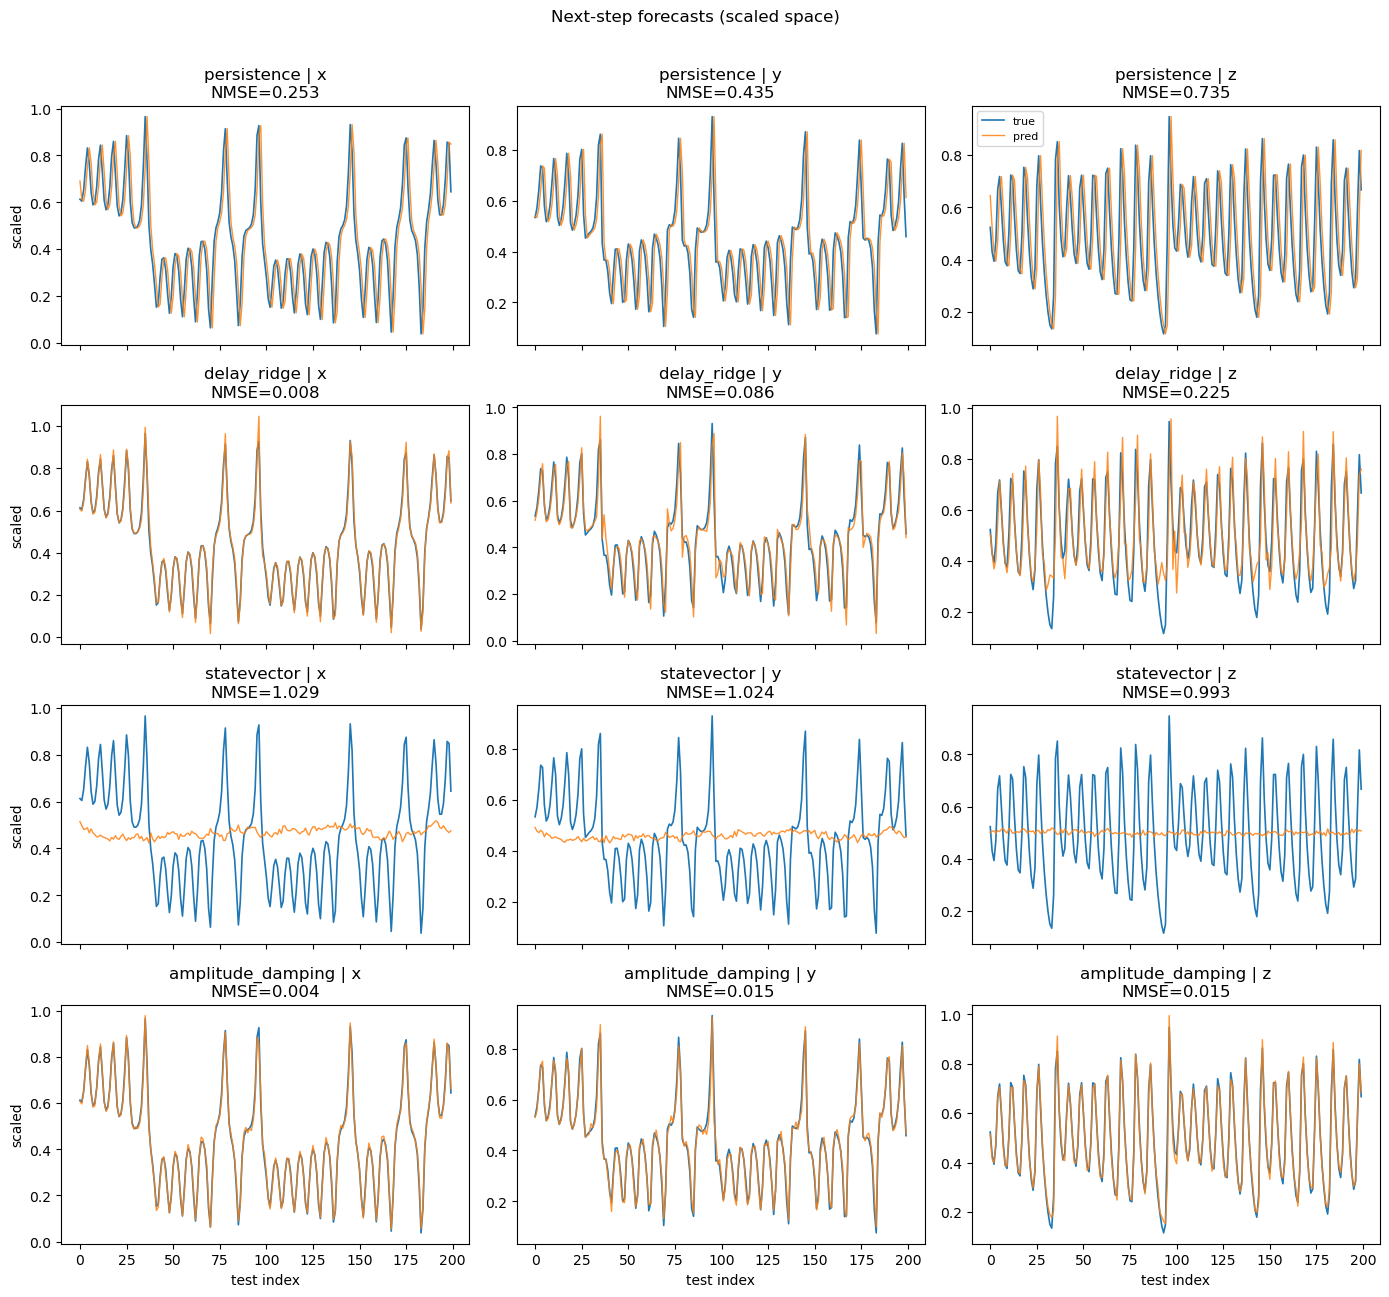

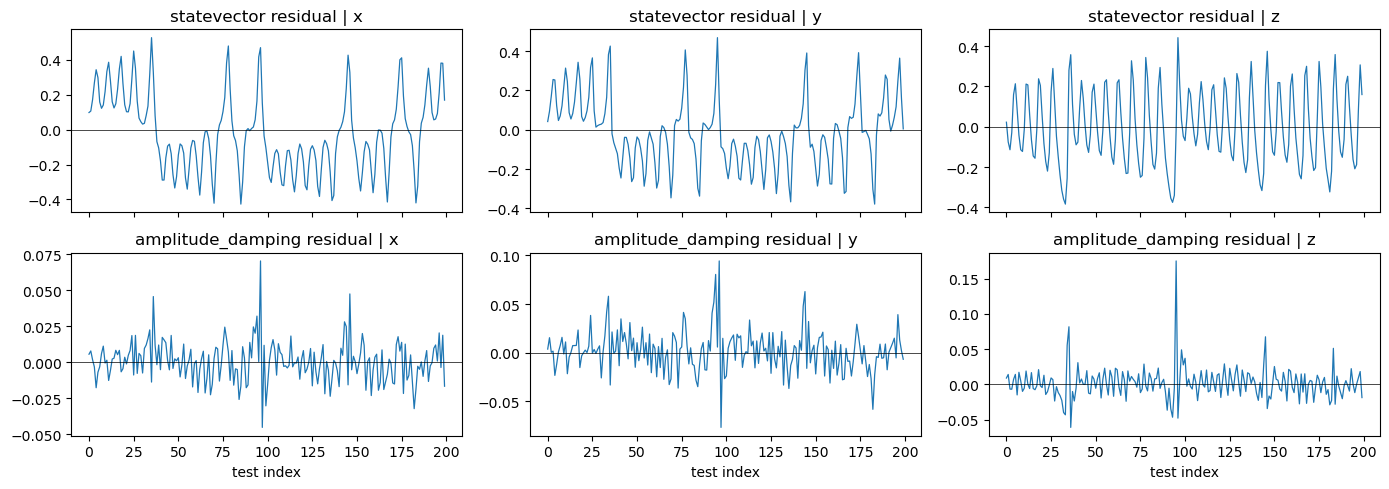

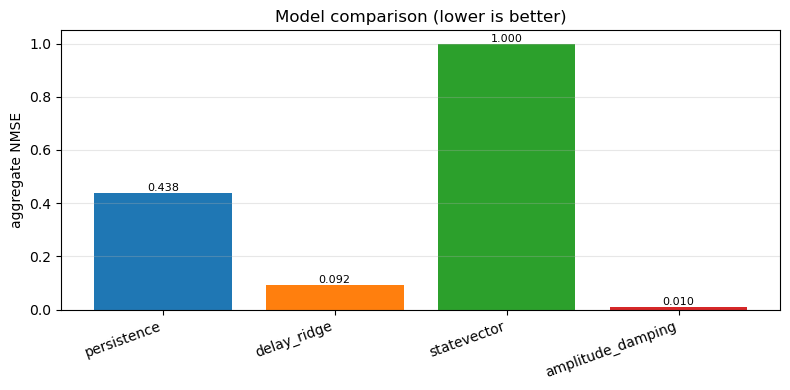

In [11]:
# ── Forecast / residual / comparison plots ───────────────────────────────────
var_names = LORENZ_CONFIG["var_names"]
plot_models = [
    ("persistence", persist_summary),
    ("delay_ridge", delay_summary),
    ("statevector", lorenz_summaries["statevector"]),
    ("amplitude_damping", lorenz_summaries["amplitude_damping"]),
]

fig, axes = plt.subplots(len(plot_models), 3, figsize=(14, 3.2 * len(plot_models)), sharex=True)
for r, (name, s) in enumerate(plot_models):
    yt = np.asarray(s["y_test"])
    yp = np.asarray(s["yhat"])
    for c, vname in enumerate(var_names):
        ax = axes[r][c]
        ax.plot(yt[:, c], label="true", lw=1.2)
        ax.plot(yp[:, c], label="pred", lw=1.0, alpha=0.85)
        ax.set_title(f"{name} | {vname}\nNMSE={s['ensemble_nmse_per_var'][vname]:.3f}")
        if r == len(plot_models) - 1:
            ax.set_xlabel("test index")
        if c == 0:
            ax.set_ylabel("scaled")
        if r == 0 and c == 2:
            ax.legend(fontsize=8)
fig.suptitle("Next-step forecasts (scaled space)", y=1.01)
fig.tight_layout()
plt.show()

# Residuals for QRC backends
fig, axes = plt.subplots(2, 3, figsize=(14, 5), sharex=True)
for r, backend in enumerate(BACKENDS_TO_RUN):
    s = lorenz_summaries[backend]
    resid = np.asarray(s["y_test"]) - np.asarray(s["yhat"])
    for c, vname in enumerate(var_names):
        ax = axes[r][c]
        ax.plot(resid[:, c], lw=0.9)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title(f"{backend} residual | {vname}")
        if r == 1:
            ax.set_xlabel("test index")
fig.tight_layout()
plt.show()

# Compact bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names = list(all_models.keys())
vals = [all_models[n]["ensemble_nmse"] for n in names]
bars = ax.bar(range(len(names)), vals, color=["C0", "C1", "C2", "C3"][:len(names)])
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("aggregate NMSE")
ax.set_title("Model comparison (lower is better)")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## OTOC + STM (Sagawa / Sci. Rep. 2020)

Uses artifacts from the Lorenz QRC runs (same $J$, same train features).

**OTOC** ([Kutvonen, Fujii, Sagawa, Sci. Rep. 2020](https://doi.org/10.1038/s41598-020-71673-9), Eq. 9):
$$
O(t)=\frac{1}{N_s}\sum_{j\neq \mathrm{drive}}
\frac{1}{2^{N_s}}\mathrm{Re}\,\mathrm{Tr}\big[Z_{\mathrm{d}}(t_0)\,Z_j(t_0+t)\,Z_{\mathrm{d}}(t_0)\,Z_j(t_0+t)\big]
$$
- Computed **noiseless only** (8-qubit noisy SuperOp is infeasible ≈ 64 GiB)
- Separately for each of the 3 drive qubits; report per-drive and mean curves across seeds

**STM:** $R(d)=\mathrm{corr}^2(\hat u_{t-d}, u_{t-d})$, $\mathrm{MC}=\sum_d R(d)$ separately for $x,y,z$ on both backends.


In [12]:
# ── OTOC utilities — Sagawa / Sci. Rep. 2020 (FC-TFI QRC) ────────────────────
def _embed_1q(op2, q, n_qubits):
    mats = [op2 if i == q else np.eye(2, dtype=complex) for i in range(n_qubits)]
    full = np.array([[1.0]], dtype=complex)
    for i in range(n_qubits - 1, -1, -1):
        full = np.kron(full, mats[i])
    return full


def build_otoc_step_circuit(ising_params, n_qubits, num_layers, n_trotter_steps):
    """One Ising scrambling step (no RY) — same Trotter content as reservoir layers."""
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
    return qc


def make_otoc_heisenberg_step(
    ising_params,
    n_qubits,
    num_layers,
    n_trotter_steps,
    backend="statevector",
    gamma=0.0,
    seed=42,
):
    """Return op -> Φ*(op) for one OTOC step.

    Only statevector (unitary) is supported at 8 qubits — noisy SuperOp is infeasible.
    """
    if backend != "statevector" and float(gamma) > 0.0:
        raise ValueError(
            "Noisy OTOC SuperOp is infeasible at 8 qubits; use backend='statevector'."
        )
    qc = build_otoc_step_circuit(ising_params, n_qubits, num_layers, n_trotter_steps)
    U = Operator(qc).data
    Udag = U.conj().T

    def step(op):
        return Udag @ op @ U

    return step, {"channel": "unitary"}


def otoc_sagawa(
    ising_params,
    n_qubits,
    n_steps,
    drive_qubit,
    num_layers,
    n_trotter_steps,
    backend="statevector",
    gamma=0.0,
    seed=42,
):
    """Sagawa / Sci. Rep. 2020 Eq. 9 for FC-TFI QRC (noiseless)."""
    Ns = n_qubits
    d = 2 ** Ns
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    Zd = _embed_1q(Z, drive_qubit, Ns)

    targets = [q for q in range(Ns) if q != drive_qubit]
    if len(targets) == 0:
        raise ValueError(
            f"Sagawa OTOC needs ≥1 non-drive qubit; got n_qubits={Ns}, drive={drive_qubit}."
        )

    heisenberg_step, meta = make_otoc_heisenberg_step(
        ising_params, Ns, num_layers, n_trotter_steps,
        backend=backend, gamma=gamma, seed=seed,
    )

    Zj_t = {q: _embed_1q(Z, q, Ns).copy() for q in targets}
    O = np.zeros(n_steps + 1)
    for t in range(n_steps + 1):
        acc = 0.0
        for q in targets:
            Zj = Zj_t[q]
            acc += np.trace(Zd @ Zj @ Zd @ Zj).real / d
        O[t] = acc / Ns

        for q in targets:
            Zj_t[q] = heisenberg_step(Zj_t[q])
    return O, meta


def otoc_sagawa_stats(O):
    """Decay diagnostics matching Sagawa interpretation."""
    o0 = float(O[0])
    of = float(O[-1])
    half = 0.5 * (o0 + of)
    below = np.where(O <= half)[0]
    t_half = int(below[0]) if len(below) else None

    half0 = 0.5 * o0
    below0 = np.where(O <= half0)[0]
    t_half0 = int(below0[0]) if len(below0) else None

    k = min(5, len(O) - 1)
    early_slope = float((O[k] - O[0]) / k) if k > 0 else np.nan

    return {
        "O0": o0,
        "O_final": of,
        "t_half": t_half,
        "t_half0": t_half0,
        "early_slope": early_slope,
    }


In [13]:
# ── STM memory capacity from stored reservoir features ───────────────────────
def stm_memory_curve(H, u, max_delay=50, alpha=1.0):
    """Short-term memory capacity curve R(d) and MC = Σ R(d).

    Target at time t is u[t-d]; features are H[t] (Kutvonen / Jaeger STM).
    u may be 1D (single variable).
    """
    H = np.asarray(H, dtype=float)
    u = np.asarray(u, dtype=float).reshape(-1)
    assert len(H) == len(u)
    R = np.zeros(max_delay + 1)
    for d in range(1, max_delay + 1):
        if d >= len(u) - 2:
            break
        X = H[d:]
        y = u[:-d]
        n_tr = int(0.7 * len(y))
        model = Ridge(alpha=alpha)
        model.fit(X[:n_tr], y[:n_tr])
        yhat = model.predict(X[n_tr:])
        yte = y[n_tr:]
        if np.var(yte) < 1e-15 or np.var(yhat) < 1e-15:
            R[d] = 0.0
        else:
            R[d] = float(np.corrcoef(yte, yhat)[0, 1] ** 2)
            if not np.isfinite(R[d]):
                R[d] = 0.0
    mc = float(np.sum(R[1:]))
    return R, mc


=== Noiseless OTOC (per drive qubit, all seeds) ===

--- seed/iter 0 ---
  drive=x (q0): O0=0.8750 O_final=0.7783 early_slope=-0.00212
  drive=y (q1): O0=0.8750 O_final=0.7160 early_slope=-0.00247
  drive=z (q2): O0=0.8750 O_final=0.7310 early_slope=-0.00312

--- seed/iter 1 ---
  drive=x (q0): O0=0.8750 O_final=0.8425 early_slope=-0.00105
  drive=y (q1): O0=0.8750 O_final=0.8156 early_slope=-0.00185
  drive=z (q2): O0=0.8750 O_final=0.7998 early_slope=-0.00206

--- seed/iter 2 ---
  drive=x (q0): O0=0.8750 O_final=0.7908 early_slope=-0.00204
  drive=y (q1): O0=0.8750 O_final=0.7927 early_slope=-0.00202
  drive=z (q2): O0=0.8750 O_final=0.8187 early_slope=-0.00152

=== STM (per variable, both backends, last-iter features) ===
  statevector | x: MC=0.351
  statevector | y: MC=0.316
  statevector | z: MC=0.149
  statevector | mean MC=0.272
  amplitude_damping | x: MC=2.148
  amplitude_damping | y: MC=2.564
  amplitude_damping | z: MC=6.869
  amplitude_damping | mean MC=3.861

======== Di

cell_19:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


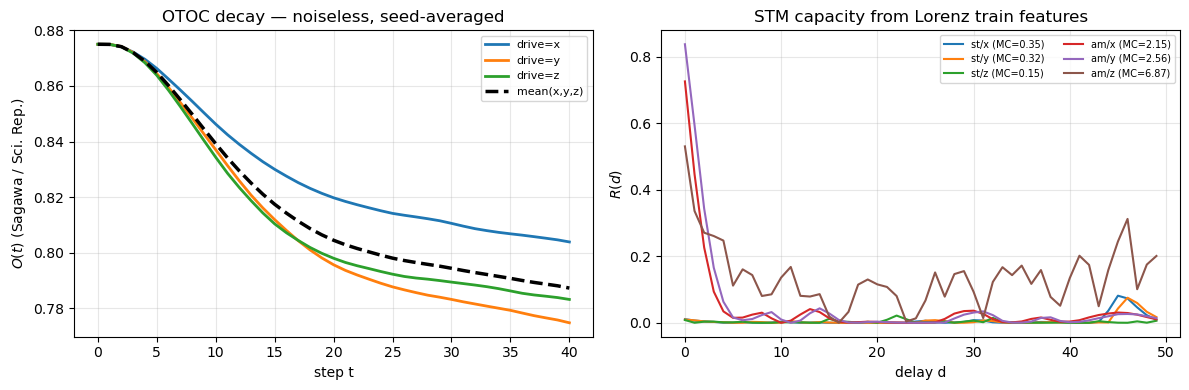

In [14]:
# ── Sagawa OTOC (noiseless, per drive) + multivariate STM ────────────────────
var_names = LORENZ_CONFIG["var_names"]
n_drive = QRC_CONFIG["n_drive_qubits"]

# OTOC: noiseless only, all seeds × all drive qubits
otoc_results = {v: [] for v in var_names}  # list of O curves per seed
print("=== Noiseless OTOC (per drive qubit, all seeds) ===")
for it, rec in enumerate(lorenz_summaries["statevector"]["results"]):
    ising = rec["ising"]
    print(f"\n--- seed/iter {it} ---")
    for d_idx, vname in enumerate(var_names):
        O, meta = otoc_sagawa(
            ising,
            n_qubits,
            n_steps=OTOC_CONFIG["n_steps"],
            drive_qubit=d_idx,
            num_layers=QRC_CONFIG["num_layers_per_event"],
            n_trotter_steps=QRC_CONFIG.get("n_trotter_steps", 3),
            backend="statevector",
            gamma=0.0,
            seed=QRC_CONFIG["random_seed"] + it,
        )
        stats = otoc_sagawa_stats(O)
        otoc_results[vname].append({"O": O, "stats": stats, "iter": it})
        print(f"  drive={vname} (q{d_idx}): O0={stats['O0']:.4f} "
              f"O_final={stats['O_final']:.4f} early_slope={stats['early_slope']:.5f}")

# Mean O(t) across seeds for each drive + grand mean
otoc_mean = {}
for vname in var_names:
    stack = np.stack([r["O"] for r in otoc_results[vname]], axis=0)
    otoc_mean[vname] = stack.mean(axis=0)
otoc_grand_mean = np.mean([otoc_mean[v] for v in var_names], axis=0)

# STM: both backends, last-iter artifacts, per variable
stm_results = {}  # backend -> {var: {R, MC}}
print("\n=== STM (per variable, both backends, last-iter features) ===")
for backend in BACKENDS_TO_RUN:
    art = lorenz_summaries[backend]["artifacts"]
    H_tr = art["H_train"]
    U_tr = art["U_train"]  # (n_tr_pairs, 3) clipped encoding inputs
    stm_results[backend] = {}
    mcs = []
    for d_idx, vname in enumerate(var_names):
        R, mc = stm_memory_curve(
            H_tr, U_tr[:, d_idx],
            max_delay=min(50, len(U_tr) // 4),
            alpha=1.0,
        )
        stm_results[backend][vname] = {"R": R, "MC": mc}
        mcs.append(mc)
        print(f"  {backend} | {vname}: MC={mc:.3f}")
    stm_results[backend]["mean_MC"] = float(np.mean(mcs))
    print(f"  {backend} | mean MC={stm_results[backend]['mean_MC']:.3f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for vname in var_names:
    ax.plot(otoc_mean[vname], label=f"drive={vname}", lw=2)
ax.plot(otoc_grand_mean, label="mean(x,y,z)", lw=2.5, ls="--", color="k")
ax.set_xlabel("step t")
ax.set_ylabel(r"$O(t)$ (Sagawa / Sci. Rep.)")
ax.set_title("OTOC decay — noiseless, seed-averaged")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for backend in BACKENDS_TO_RUN:
    for vname in var_names:
        rec = stm_results[backend][vname]
        ax.plot(
            rec["R"][1:],
            label=f"{backend[:2]}/{vname} (MC={rec['MC']:.2f})",
            lw=1.5,
        )
ax.set_xlabel("delay d")
ax.set_ylabel(r"$R(d)$")
ax.set_title("STM capacity from Lorenz train features")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print("\n======== Diagnostics summary ========")
print(f"{'drive':<6} {'O0_mean':>10} {'O_final':>10} {'early_slope':>12}")
for vname in var_names:
    Os = [r["O"] for r in otoc_results[vname]]
    Omean = np.mean(Os, axis=0)
    st = otoc_sagawa_stats(Omean)
    print(f"{vname:<6} {st['O0']:10.4f} {st['O_final']:10.4f} {st['early_slope']:12.5f}")

print(f"\n{'backend':<22} {'MC_x':>8} {'MC_y':>8} {'MC_z':>8} {'MC_mean':>8} {'QRC_NMSE':>10}")
for backend in BACKENDS_TO_RUN:
    print(
        f"{backend:<22} "
        f"{stm_results[backend]['x']['MC']:8.3f} "
        f"{stm_results[backend]['y']['MC']:8.3f} "
        f"{stm_results[backend]['z']['MC']:8.3f} "
        f"{stm_results[backend]['mean_MC']:8.3f} "
        f"{lorenz_summaries[backend]['ensemble_nmse']:10.4f}"
    )

# Final sanity: no NaNs in key metrics
for backend in BACKENDS_TO_RUN:
    assert np.isfinite(lorenz_summaries[backend]["ensemble_nmse"])
assert np.isfinite(persist_summary["ensemble_nmse"])
assert np.isfinite(delay_summary["ensemble_nmse"])
print("\nAll finite-metric assertions passed.")
